# 04 — North–South Yield Convergence

**Research Question 3:** *Are Southern EU countries converging or diverging from Northern EU yield levels?*

This notebook computes the **regional yield gap** — Northern minus Southern weighted regional yield — for each crop, year by year. A shrinking gap indicates convergence; a stable or growing gap indicates persistent structural difference.

### Regional grouping

| North | South |
|---|---|
| Germany | Italy |
| France | Spain |
| Netherlands | Portugal |

### Methodological note: weighted vs. unweighted aggregation

Regional yield is computed as **Σ production ÷ Σ area** across the three countries in the region, *not* as the mean of the three per-country yields. The weighted formulation is correct because it respects the relative size of each producer: France's wheat output dwarfs the Netherlands', so France should dominate the Northern wheat figure proportionally. A simple mean would give Portugal the same weight as France, distorting the regional picture.


## 1. Imports and configuration


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

NORTH = ["Germany", "France", "Netherlands"]
SOUTH = ["Italy", "Spain", "Portugal"]

GROUP_COLS = ["Item", "Year"]
AGG_COLS = ["production_t", "area_ha"]


## 2. Load processed data


In [2]:
eu_stat_joined = pd.read_csv(DATA_DIR / "processed" / "eu_stat_joined.csv")
print(f"Shape: {eu_stat_joined.shape}")
eu_stat_joined.head()


Shape: (720, 6)


,Area,Item,Year,production_t,area_ha,Annual Yield (t/ha)
0,France,Grapes,1995,7212900.0,894800.0,8.060907
1,France,Grapes,1996,7716400.0,886690.0,8.702478
2,France,Grapes,1997,7190900.0,878148.0,8.188711
3,France,Grapes,1998,6919069.0,862677.0,8.020463
4,France,Grapes,1999,8040710.0,863355.0,9.313330


## 3. Compute weighted regional yield

A small helper function encapsulates the aggregation logic so it can be applied to either region without code duplication. Type hints and a full docstring follow PEP 257 and modern German Python style guides.


In [3]:
def regional_yield(df: pd.DataFrame, countries: list[str]) -> pd.DataFrame:
    """Compute weighted regional yield across selected countries.

    Aggregates production and harvested area across the supplied countries,
    then computes yield as total production divided by total area. This
    produces a weighted average rather than a simple mean of per-country
    yields, so larger producers contribute proportionally to the regional
    figure.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format dataframe containing 'Area', 'Item', 'Year',
        'production_t', and 'area_ha' columns.
    countries : list[str]
        Country names to aggregate.

    Returns
    -------
    pd.DataFrame
        Indexed by ('Item', 'Year') with a single 'regional_yield' column
        in tonnes per hectare.
    """
    agg = (
        df[df["Area"].isin(countries)]
        .groupby(GROUP_COLS)[AGG_COLS]
        .sum()
    )
    agg["regional_yield"] = agg["production_t"] / agg["area_ha"]
    return agg[["regional_yield"]]


## 4. Compute the North–South gap

Apply the helper to each region, merge on (Item, Year), and compute the gap. The `validate="one_to_one"` argument is a defensive check. Any other cardinality would indicate a duplicate row that needs investigation.


In [4]:
regional_y = (
    regional_yield(eu_stat_joined, NORTH)
    .merge(
        regional_yield(eu_stat_joined, SOUTH),
        on=GROUP_COLS,
        suffixes=("_north", "_south"),
        validate="one_to_one",
    )
)

regional_y["gap"] = (
    regional_y["regional_yield_north"] - regional_y["regional_yield_south"]
)
regional_y = regional_y.reset_index()

regional_y.head()


,Item,Year,regional_yield_north,regional_yield_south,gap
0,Grapes,1995,8.716771,5.560482,3.156288
1,Grapes,1996,9.078189,6.987055,2.091134
2,Grapes,1997,8.502459,6.445990,2.056469
3,Grapes,1998,8.691598,6.724745,1.966854
4,Grapes,1999,10.054784,7.251167,2.803617


## 5. Smooth with a 3-year rolling average

Annual yield is volatile because of weather. A 3-year centred rolling average separates the structural trend (the convergence question) from year-to-year noise (a weather question). The smoothed series is plotted as a bold line over the faint raw series, giving the reader both views simultaneously.


In [5]:
regional_y = regional_y.sort_values(["Item", "Year"]).copy()

regional_y["gap_smooth"] = (
    regional_y
    .groupby("Item")["gap"]
    .transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())
)

regional_y.head()


,Item,Year,regional_yield_north,regional_yield_south,gap,gap_smooth
0,Grapes,1995,8.716771,5.560482,3.156288,2.623711
1,Grapes,1996,9.078189,6.987055,2.091134,2.434630
2,Grapes,1997,8.502459,6.445990,2.056469,2.038152
3,Grapes,1998,8.691598,6.724745,1.966854,2.275647
4,Grapes,1999,10.054784,7.251167,2.803617,2.340470


## 6. Visualise convergence per crop

Each panel is one crop. The faint line shows the annual gap; the bold line is the 3-year rolling average. Background shading distinguishes "North leads" (green, gap > 0) from "South leads" (orange, gap < 0). Independent y-axes (`sharey=False`) prevent the large sugar-beet range from compressing the other crops.


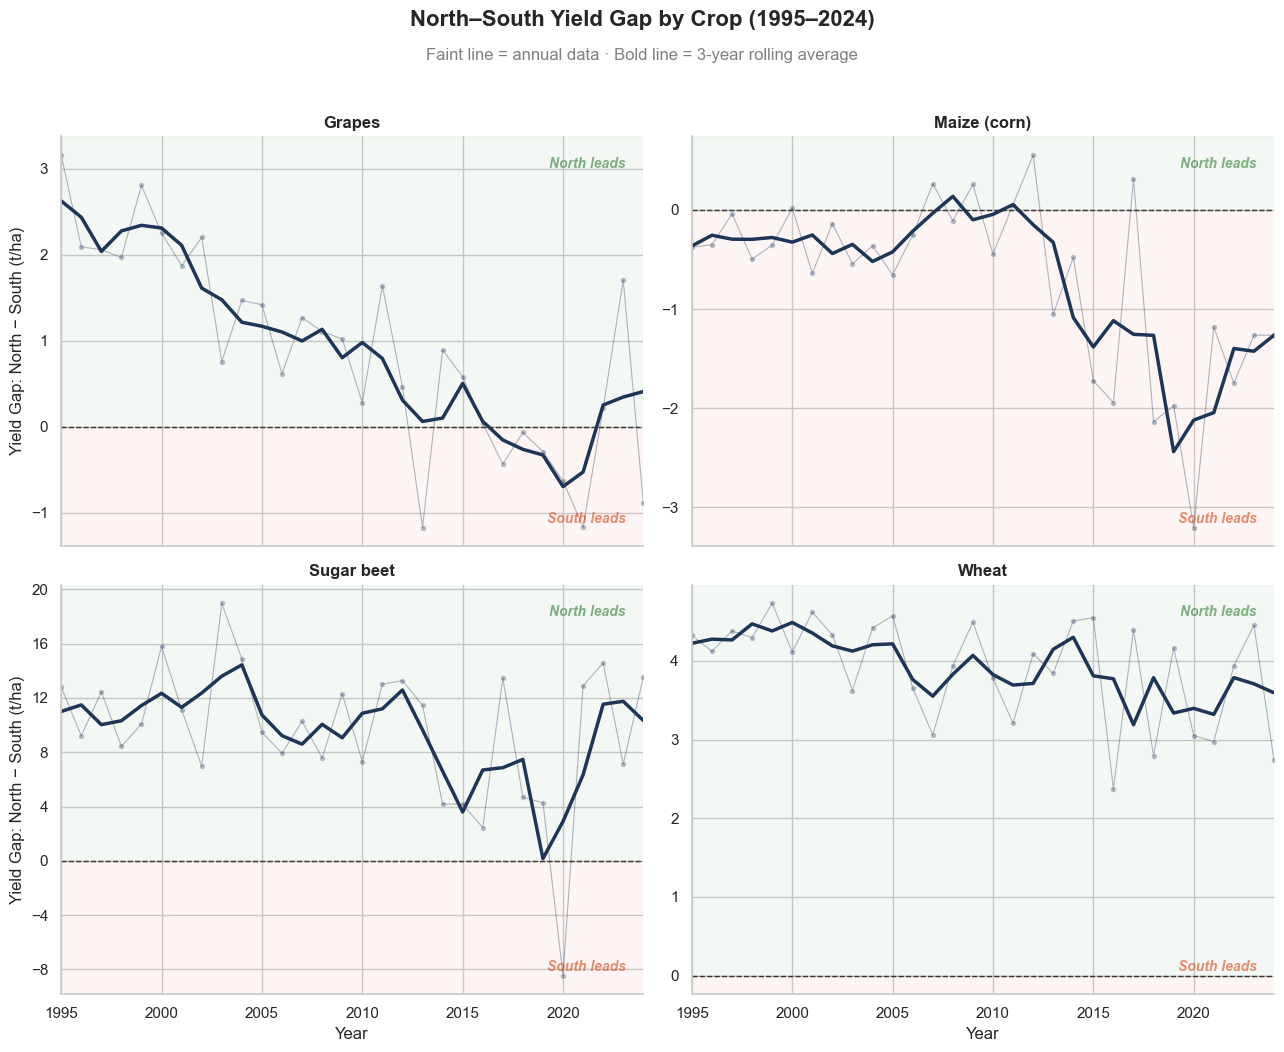

In [6]:
# Faint annual line
g = sns.relplot(
    data=regional_y,
    x="Year",
    y="gap",
    col="Item",
    col_wrap=2,
    kind="line",
    color="#1D3557",
    marker="o",
    markersize=4,
    linewidth=0.8,
    alpha=0.35,
    height=5,
    aspect=1.3,
    facet_kws={"sharey": False},
)

# Per-facet styling and rolling-average overlay
for ax, crop in zip(g.axes.flat, g.col_names):
    crop_data = regional_y[regional_y["Item"] == crop]

    # Bold smoothed line
    ax.plot(
        crop_data["Year"], crop_data["gap_smooth"],
        color="#1D3557", linewidth=2.5,
    )

    # Zero reference
    ax.axhline(0, color="#333333", linewidth=1, linestyle="--")

    # Zone shading
    ylim = ax.get_ylim()
    ax.axhspan(0, ylim[1], color="#2E7D32", alpha=0.05)
    ax.axhspan(ylim[0], 0, color="#D84315", alpha=0.05)
    ax.set_ylim(ylim)

    # Zone labels
    ax.text(0.97, 0.95, "North leads", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color="#2E7D32", alpha=0.6,
            ha="right", va="top", style="italic")
    ax.text(0.97, 0.05, "South leads", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color="#D84315", alpha=0.6,
            ha="right", va="bottom", style="italic")

    # Clean ticks
    ax.set_xlim(1995, 2024)
    ax.set_xticks(np.arange(1995, 2025, 5))
    ax.tick_params(axis="x", rotation=0)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

g.set_axis_labels("Year", "Yield Gap: North − South (t/ha)")
g.set_titles("{col_name}", fontsize=13, fontweight="bold")

g.figure.suptitle(
    "North–South Yield Gap by Crop (1995–2024)",
    fontsize=16, fontweight="bold", y=1.05,
)
g.figure.text(
    0.5, 1.00,
    "Faint line = annual data · Bold line = 3-year rolling average",
    ha="center", fontsize=12, color="gray",
)

g.figure.tight_layout()
g.figure.savefig(FIGURES_DIR / "north_south_yield_gap.png",
                 dpi=400, bbox_inches="tight")
plt.show()


## Summary of findings

**Grapes — clear convergence.** The Northern lead has shrunk from roughly +3 t/ha in 1995 to near zero by 2020, with the South briefly overtaking the North in some recent years. This is the strongest convergence signal in the dataset.

**Maize — convergence and crossover.** The gap has not only closed but reversed: since around 2015, Southern producers (particularly Spain) consistently out-yield the Northern average. The structural advantage of irrigated Mediterranean maize farming is now visible in the data.

**Wheat — stable structural gap.** The Northern lead has remained at ~3.5–4.5 t/ha across the entire period. There is no convergence trend; this is a persistent structural difference driven by climate and soil suitability for wheat.

**Sugar beet — large but volatile gap.** The Northern lead averages ~10 t/ha but oscillates substantially, with a notable dip around 2020 (likely linked to Portugal's data dropout and exceptional weather). Without those anomalies the gap is structurally stable.

###

Two crops (grapes, maize) show genuine convergence, suggesting that productivity-enhancing technology and practices have transferred southward effectively. Two crops (wheat, sugar beet) show persistent gaps that are likely climatic in origin and unlikely to close through technology alone. A sustainable EU biomass strategy should therefore differentiate by crop: invest in Southern productivity for crops where convergence is achievable, and rely on regional specialization where it is not.
